In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_excel("C:/Users/ramya/Downloads/Sales data.xlsx")

In [15]:
print(df.head())

   Unnamed: 0  order_id  order_date  product_id product_category   price  \
0           0         1  2022-04-13        2637            Books  128.75   
1           1         2  2023-03-12        2300          Fashion  302.60   
2           2         3  2022-09-28        3670           Sports  495.80   
3           3         4  2022-04-17        2522            Books  371.95   
4           4         5  2022-03-13        1717           Beauty  201.68   

   discount_percent  quantity_sold customer_region payment_method  rating  \
0                10              4   North America            UPI     3.5   
1                20              5            Asia    Credit Card     3.7   
2                20              2          Europe            UPI     4.4   
3                15              4     Middle East            UPI     5.0   
4                 0              4     Middle East            UPI     4.6   

   review_count  discounted_price  total_revenue  
0           443            11

In [16]:
print(df.shape)

(50000, 14)


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50000 non-null  int64  
 1   order_id          50000 non-null  int64  
 2   order_date        50000 non-null  object 
 3   product_id        50000 non-null  int64  
 4   product_category  50000 non-null  object 
 5   price             50000 non-null  float64
 6   discount_percent  50000 non-null  int64  
 7   quantity_sold     50000 non-null  int64  
 8   customer_region   50000 non-null  object 
 9   payment_method    50000 non-null  object 
 10  rating            50000 non-null  float64
 11  review_count      50000 non-null  int64  
 12  discounted_price  50000 non-null  float64
 13  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(6), object(4)
memory usage: 5.3+ MB
None


In [18]:
print(df.describe())

         Unnamed: 0      order_id    product_id         price  \
count  50000.000000  50000.000000  50000.000000  50000.000000   
mean   24999.500000  25000.500000   2986.848740    252.507260   
std    14433.901067  14433.901067   1156.374535    143.025544   
min        0.000000      1.000000   1000.000000      5.010000   
25%    12499.750000  12500.750000   1983.000000    127.840000   
50%    24999.500000  25000.500000   2983.000000    252.970000   
75%    37499.250000  37500.250000   3989.000000    376.335000   
max    49999.000000  50000.000000   4999.000000    499.990000   

       discount_percent  quantity_sold        rating  review_count  \
count      50000.000000   50000.000000  50000.000000  50000.000000   
mean          13.340700       2.999400      2.996316    249.329280   
std            9.850694       1.415401      1.154295    144.251981   
min            0.000000       1.000000      1.000000      0.000000   
25%            5.000000       2.000000      2.000000    125.0000

In [19]:
print(df.isnull().sum())

Unnamed: 0          0
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64


In [21]:
print(df.duplicated().sum())

0


In [29]:
# 3. DATA PREPARATION
df.drop_duplicates(inplace=True)
df['order_date'] = pd.to_datetime(df['order_date'])
df['discounted_price'] = df['price'] * (1 - df['discount_percent'] / 100)
df['total_revenue'] = df['discounted_price'] * df['quantity_sold']
print(df.head())

   order_id order_date  product_id product_category   price  discount_percent  \
0         1 2022-04-13        2637            Books  128.75                10   
1         2 2023-03-12        2300          Fashion  302.60                20   
2         3 2022-09-28        3670           Sports  495.80                20   
3         4 2022-04-17        2522            Books  371.95                15   
4         5 2022-03-13        1717           Beauty  201.68                 0   

   quantity_sold customer_region payment_method  rating  review_count  \
0              4   North America            UPI     3.5           443   
1              5            Asia    Credit Card     3.7           475   
2              2          Europe            UPI     4.4           183   
3              4     Middle East            UPI     5.0           212   
4              4     Middle East            UPI     4.6           308   

   discounted_price  total_revenue  
0          115.8750         463.50  


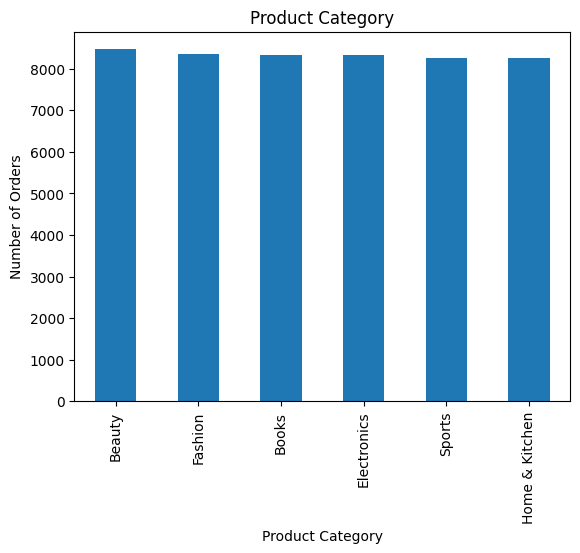

In [30]:
# Product Category
df['product_category'].value_counts().plot(kind='bar')

plt.title("Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")

plt.show()

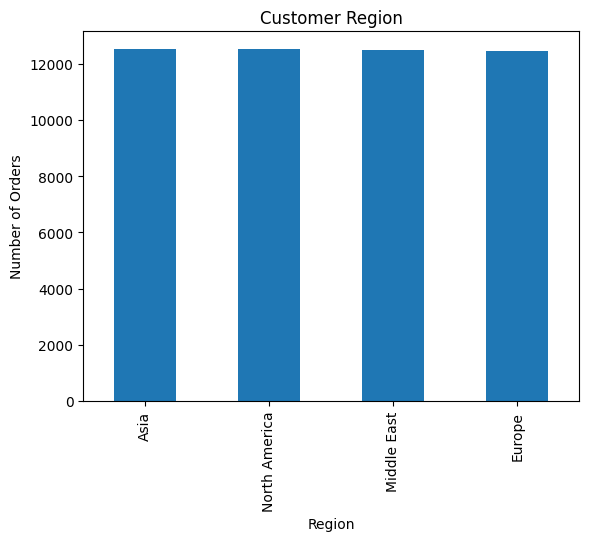

In [31]:
# Customer Region
df['customer_region'].value_counts().plot(kind='bar')

plt.title("Customer Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.show()

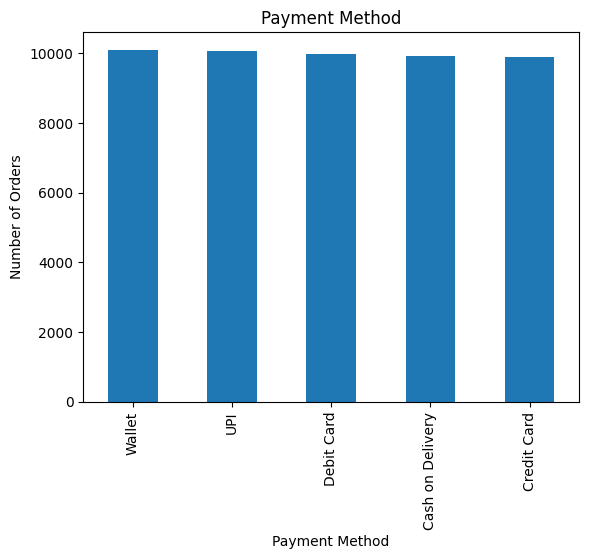

In [32]:
# Payment Method
df['payment_method'].value_counts().plot(kind='bar')
plt.title("Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

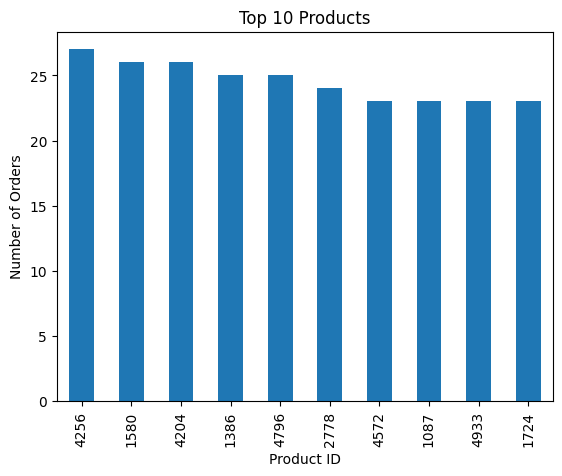

In [33]:
# Top 10 Products
df['product_id'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Orders")

plt.show()

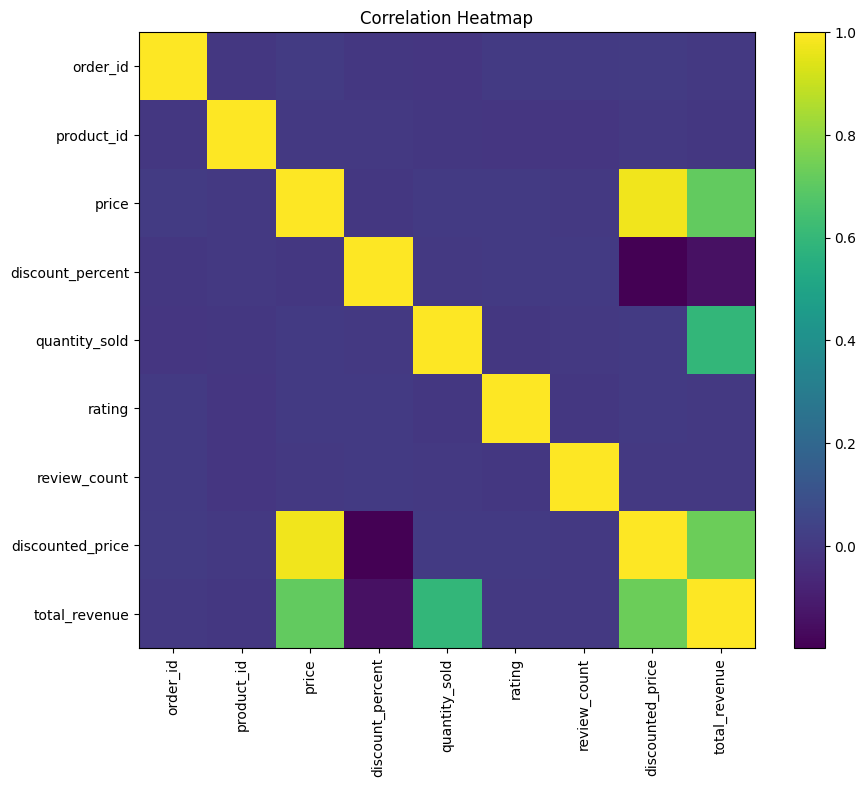

In [35]:
# Correlation Heatmap
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [36]:
# 5. EVALUATION

print("Business insights generated successfully.")
print("Sales trends, product categories, customer regions,")
print("payment methods, and revenue patterns were analyzed.")

Business insights generated successfully.
Sales trends, product categories, customer regions,
payment methods, and revenue patterns were analyzed.


In [37]:
# 6. DEPLOYMENT

print("Insights can be deployed through dashboards.")
print("The analysis can be visualized using Power BI or Tableau.")

Insights can be deployed through dashboards.
The analysis can be visualized using Power BI or Tableau.


In [38]:
# MODIFY

df.drop_duplicates(inplace=True)

df.drop(columns='Unnamed: 0', errors='ignore', inplace=True)

df['order_date'] = pd.to_datetime(df['order_date'])

df['discounted_price'] = df['price'] * (1 - df['discount_percent'] / 100)

df['total_revenue'] = df['discounted_price'] * df['quantity_sold']

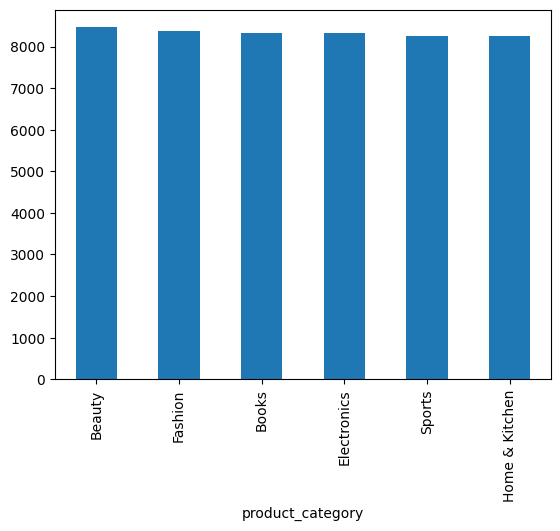

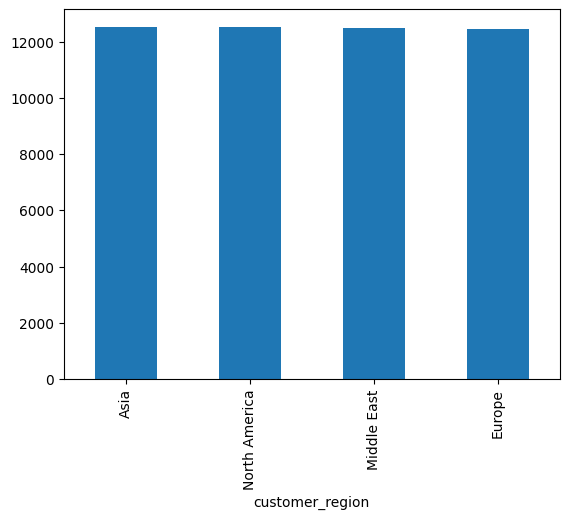

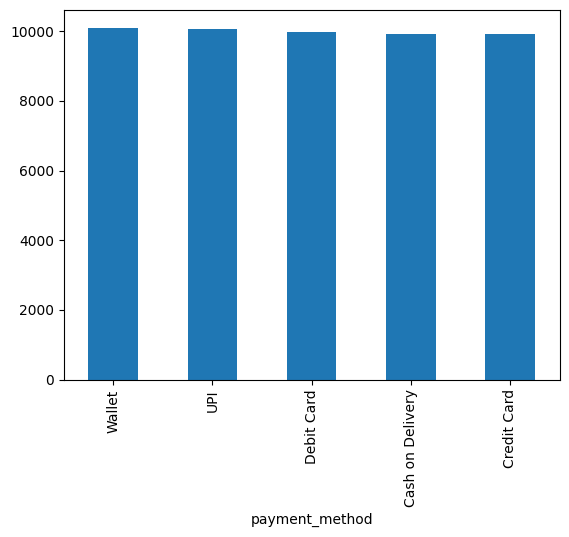

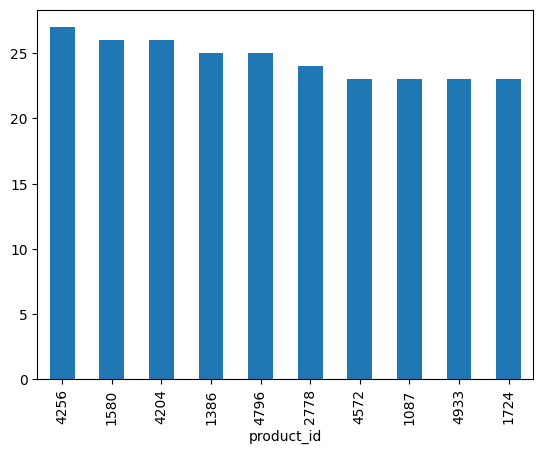

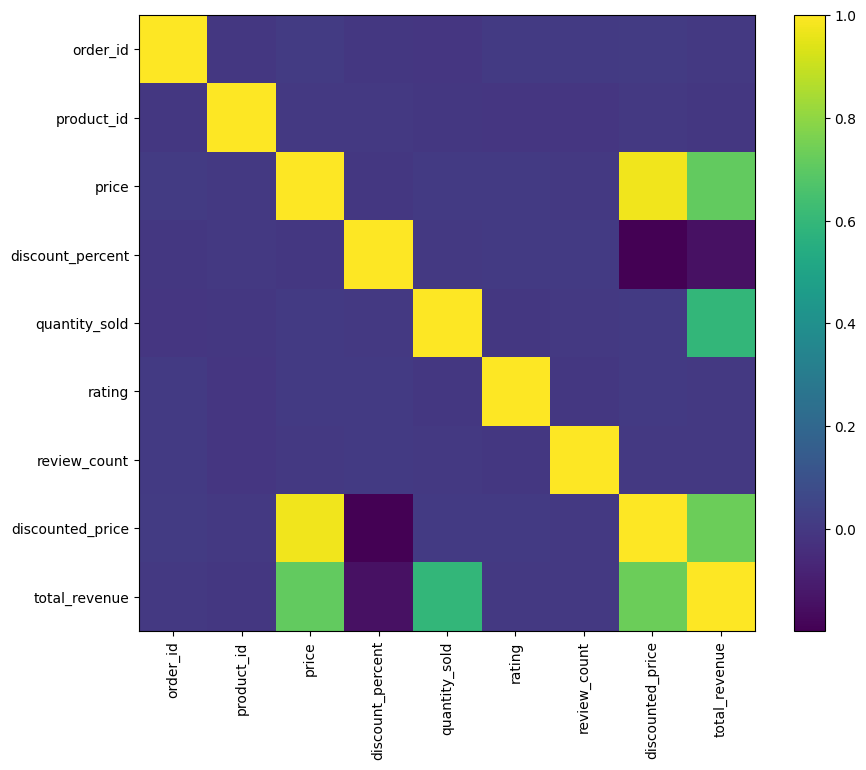

In [39]:
df['customer_region'].value_counts().plot(kind='bar')

plt.show()

df['payment_method'].value_counts().plot(kind='bar')

plt.show()

df['product_id'].value_counts().head(10).plot(kind='bar')

plt.show()

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()

In [42]:
# ASSESS

print("Sales patterns and trends successfully identified.")

Sales patterns and trends successfully identified.


In [44]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

df.drop(columns='Unnamed: 0', errors='ignore', inplace=True)

0


In [45]:
# TRANSFORMATION

df['order_date'] = pd.to_datetime(df['order_date'])

df['discounted_price'] = df['price'] * (
    1 - df['discount_percent'] / 100
)

df['total_revenue'] = (
    df['discounted_price'] * df['quantity_sold']
)

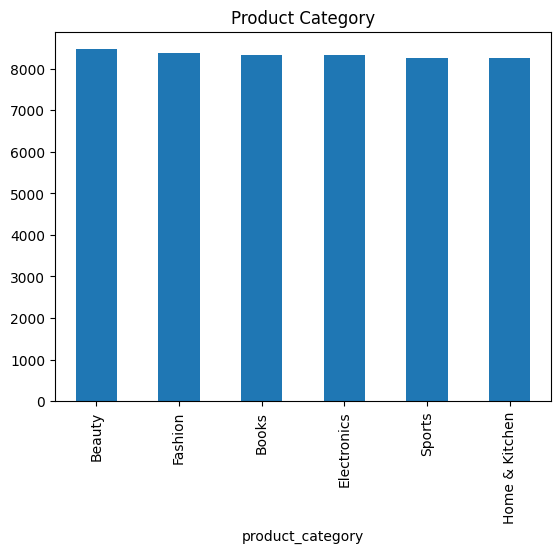

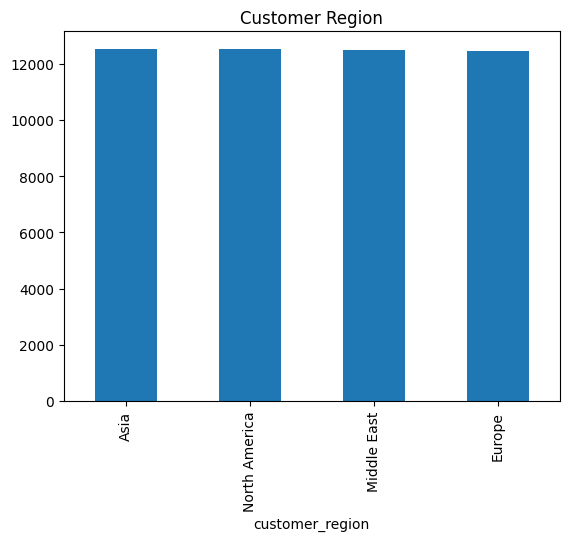

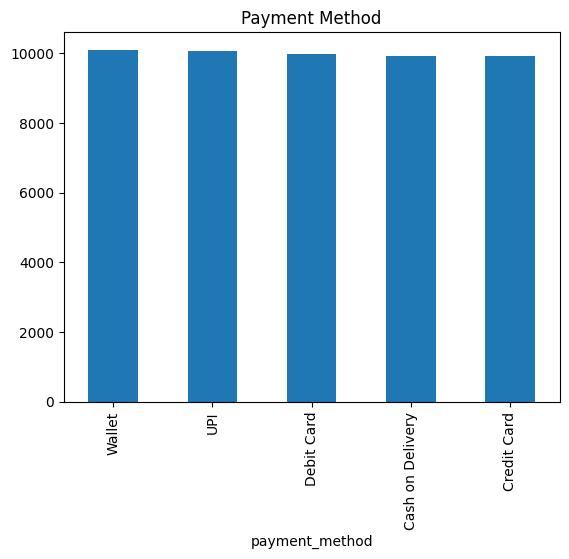

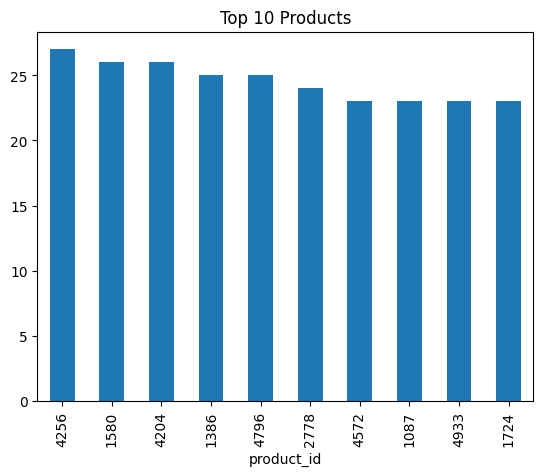

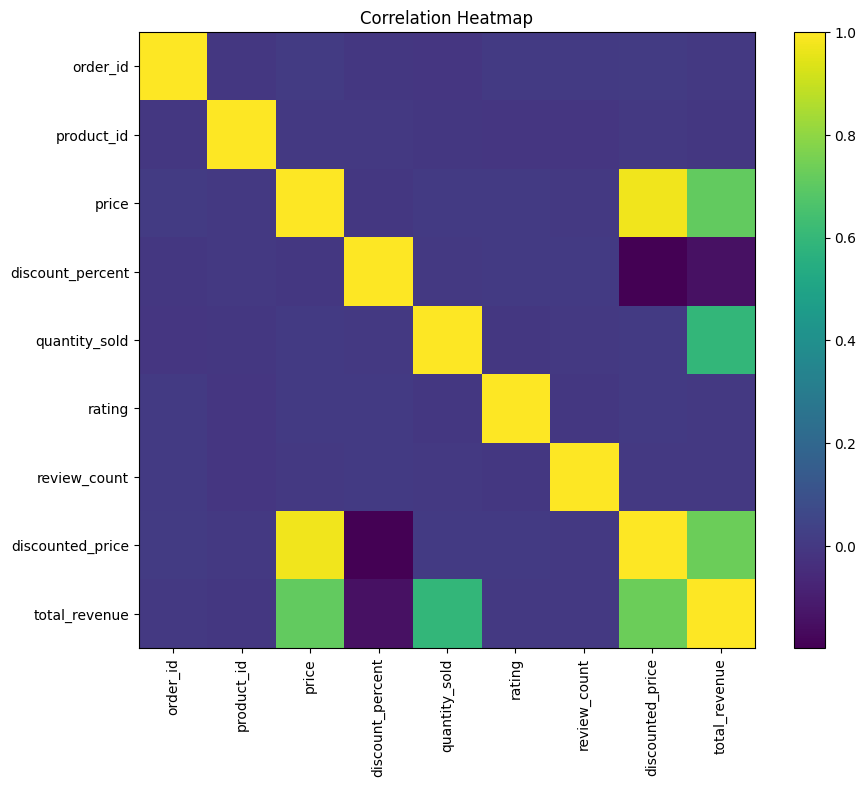

In [46]:
# DATA MINING

df['product_category'].value_counts().plot(kind='bar')

plt.title("Product Category")

plt.show()


df['customer_region'].value_counts().plot(kind='bar')

plt.title("Customer Region")

plt.show()


df['payment_method'].value_counts().plot(kind='bar')

plt.title("Payment Method")

plt.show()


df['product_id'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Products")

plt.show()


corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [47]:
# INTERPRETATION

print("Knowledge discovered from the dataset has been interpreted")
print("to support sales and business decisions.")

Knowledge discovered from the dataset has been interpreted
to support sales and business decisions.
